# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

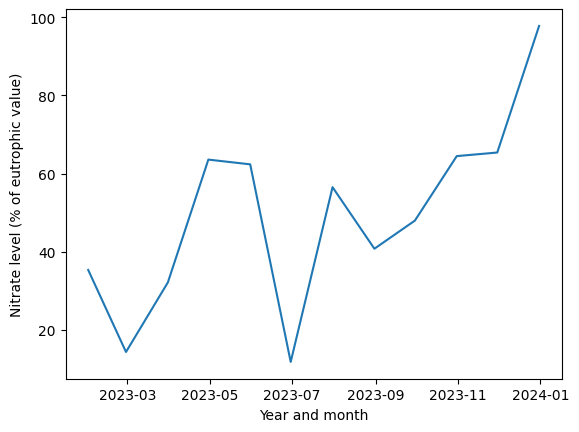

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

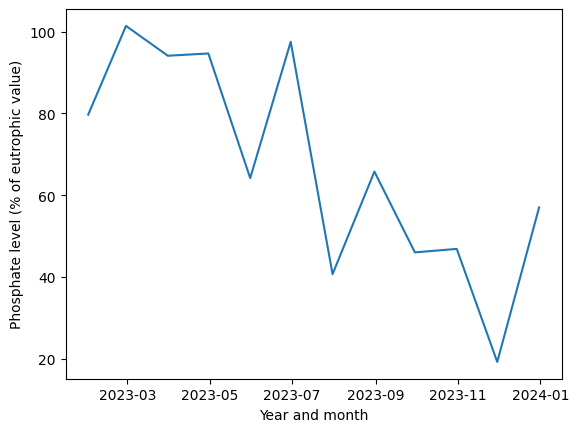

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

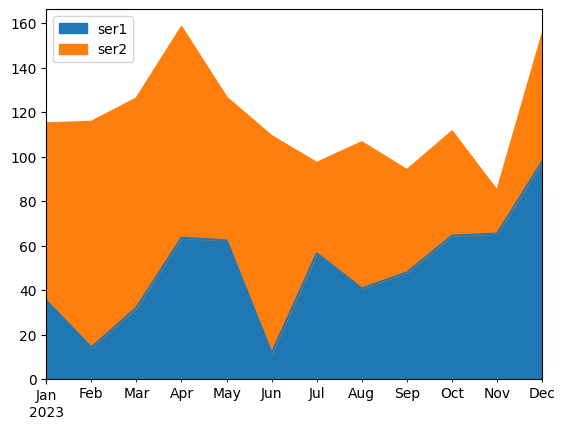

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

In [5]:
#The area plots of each variable stacked on top of each other pronounces the visualization of the difference from timepoint to timepoint
#More than simply plotting 2 line graphs side by side. # aswell as shows how much each chemical is contributing to the overall total.
#The adjustment i would make is to name the series with its corresponding variable 
#for clarity purposes in the legned of the graph. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [7]:
# Recall Brazil Cancer dataset in a way that i may commit changes to github

import os
import zipfile
import pandas as pd
import tempfile

# create temporary directory (not inside repo)
temp_dir = tempfile.gettempdir()
data_dir = os.path.join(temp_dir, "brazil_cancer_data")

os.makedirs(data_dir, exist_ok=True)

zip_path = os.path.join(data_dir, "cancer-data-brazil.zip")
csv_path = os.path.join(data_dir, "cancer_data_eng.csv")

# download if not already present
if not os.path.exists(csv_path):

    os.system(f"kaggle datasets download joaopedromedeiros/cancer-data-brazil -p {data_dir}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

df = pd.read_csv(csv_path, encoding="ISO-8859-1")

print(df.head())

/tmp/ipykernel_11939/3394368465.py:25: DtypeWarning: Columns (0: Date.of.Birth, 1: Raca.Color, 2: Nationality, 3: Naturality.State, 4: Naturality, 5: Degree.of.Education, 6: State.Civil, 7: Status.Address, 8: City.Address, 9: Youth.Adult.Illness.Description, 10: Code.of.Disease.Adult.Young., 11: Indicator.of.Rare.Case, 12: Extension, 13: Laterality, 14: Statement, 15: TNM, 16: Status.Vital, 17: Type.of.Death, 18: Date.of.Death, 19: Date.of.Last.Contact, 20: Date.of.Diagnostic, 21: Distant.metastasis) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, encoding="ISO-8859-1")


   Patient.Code              RCBP.Name     Gender Date.of.Birth   Age  \
0      672054.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1975-03-16  30.0   
1      673213.0  RCBP CAMPINAS-UNICAMP   FEMININO    1950-05-24  53.0   
2      673396.0  RCBP CAMPINAS-UNICAMP   FEMININO    1951-09-02  51.0   
3      673425.0  RCBP CAMPINAS-UNICAMP   FEMININO    1929-11-21  73.0   
4      673745.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1934-07-03  71.0   

  Raca.Color Nationality Naturality.State Naturality Degree.of.Education  ...  \
0     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   
1        NaN         NaN              NaN        NaN                 NaN  ...   
2      PARDA      BRASIL        SÃO PAULO        NaN                 NaN  ...   
3        NaN         NaN              NaN        NaN                 NaN  ...   
4     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   

  Laterality  Statement  TNM Status.Vital Type.of.Death Date.of.Death  \
0

In [8]:
#Recall data cleaning efforts from week 4.  

df["Date.of.Birth"] = pd.to_datetime(df["Date.of.Birth"], errors="coerce")
df["Date.of.Diagnostic"] = pd.to_datetime(df["Date.of.Diagnostic"], errors="coerce")

df.loc[df["Age"] >= 116, "Age"] = None
df.loc[df["Age"] <= 0, "Age"] = None


df.loc[
    df["Date.of.Birth"].isna() & df["Age"].notna(),
    "Date.of.Birth"
] = df["Date.of.Diagnostic"] - pd.to_timedelta(df["Age"] * 365.25, unit="D")

df[["Age", "Date.of.Birth"]].isnull().sum()

columns_encode = [
    "Gender",
    "Raca.Color",
    "Nationality",
    "Degree.of.Education",
    "State.Civil",
    "Status.Address",
    "Indicator.of.Rare.Case",
    "Diagnostic.means",
    "Extension",
    "Laterality",
    "Statement",
    "Status.Vital",
    "Type.of.Death",
]

df_encoded = pd.get_dummies(df, columns=columns_encode, drop_first=True)

/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/arrays/timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)


In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

numeric_cols, categorical_cols

/tmp/ipykernel_11939/283104828.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


(Index(['Patient.Code', 'Age', 'Code.Profession', 'Code.of.Morphology', 'year'], dtype='str'),
 Index(['RCBP.Name', 'Gender', 'Raca.Color', 'Nationality', 'Naturality.State',
        'Naturality', 'Degree.of.Education', 'State.Civil', 'Name.Occupation',
        'Status.Address', 'City.Address', 'Description.of.Topography',
        'Topography.Code', 'Morphology.Description', 'Description.of.Disease',
        'Illness.Code', 'Child.Illness.Description', 'Child.Illness.Code',
        'Youth.Adult.Illness.Description', 'Code.of.Disease.Adult.Young.',
        'Indicator.of.Rare.Case', 'Diagnostic.means', 'Extension', 'Laterality',
        'Statement', 'TNM', 'Status.Vital', 'Type.of.Death', 'Date.of.Death',
        'Date.of.Last.Contact', 'Distant.metastasis'],
       dtype='str'))

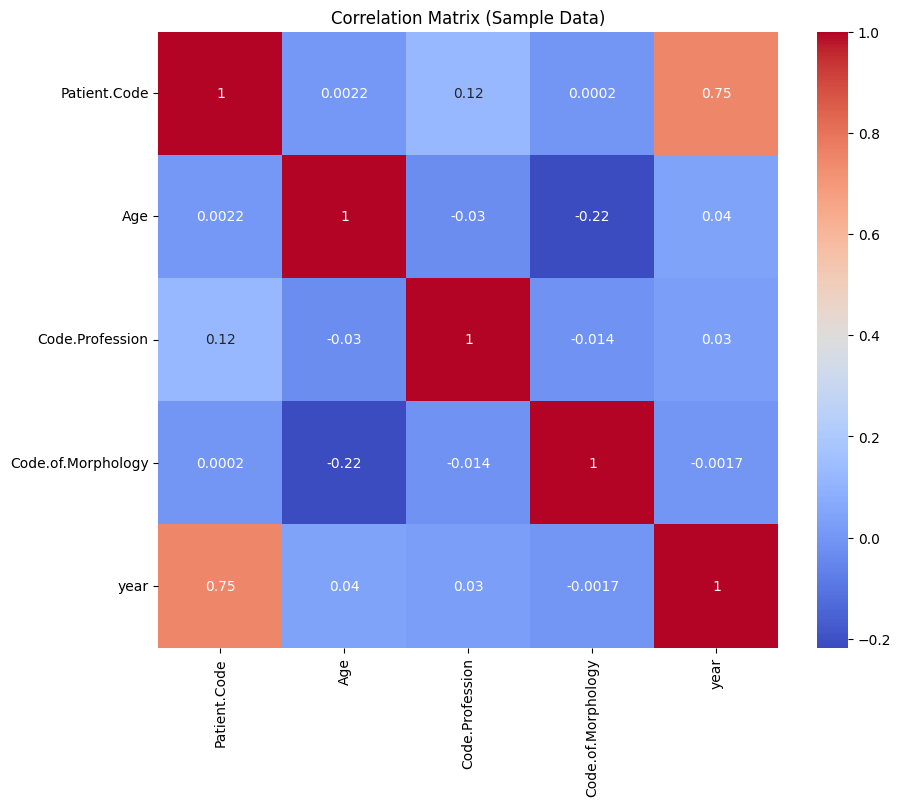

In [12]:
df_sample = df.sample(10000, random_state=42)

numeric_sample = df_sample.select_dtypes(include=["int64","float64"])

corr = numeric_sample.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Matrix (Sample Data)")
plt.show()

In [17]:
drop_cols = [
    "Patient.Code",
    "Code.Profession"
]

df_analysis = df_sample.drop(columns=drop_cols)

numeric_analysis = df_analysis.select_dtypes(include=["int64","float64"])

corr = numeric_analysis.corr()

corr_pairs = (
    corr.unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(10)

year                Age                   0.040265
Age                 year                  0.040265
Code.of.Morphology  year                 -0.001718
year                Code.of.Morphology   -0.001718
Code.of.Morphology  Age                  -0.217161
Age                 Code.of.Morphology   -0.217161
dtype: float64

<Axes: xlabel='Age', ylabel='year'>

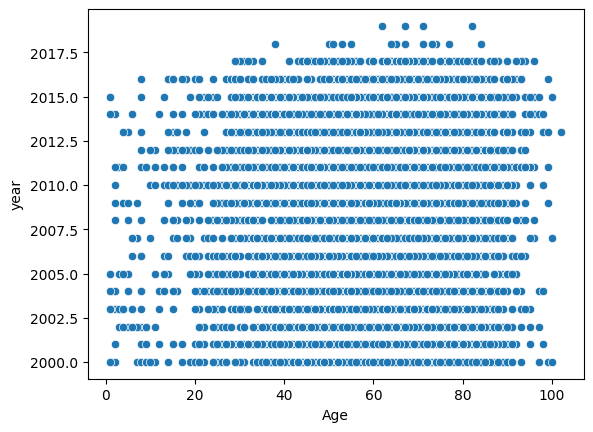

In [19]:
sns.scatterplot(data=df_sample, x="Age", y="year")

In [20]:
pair_sample = df_sample.sample(500, random_state=42)

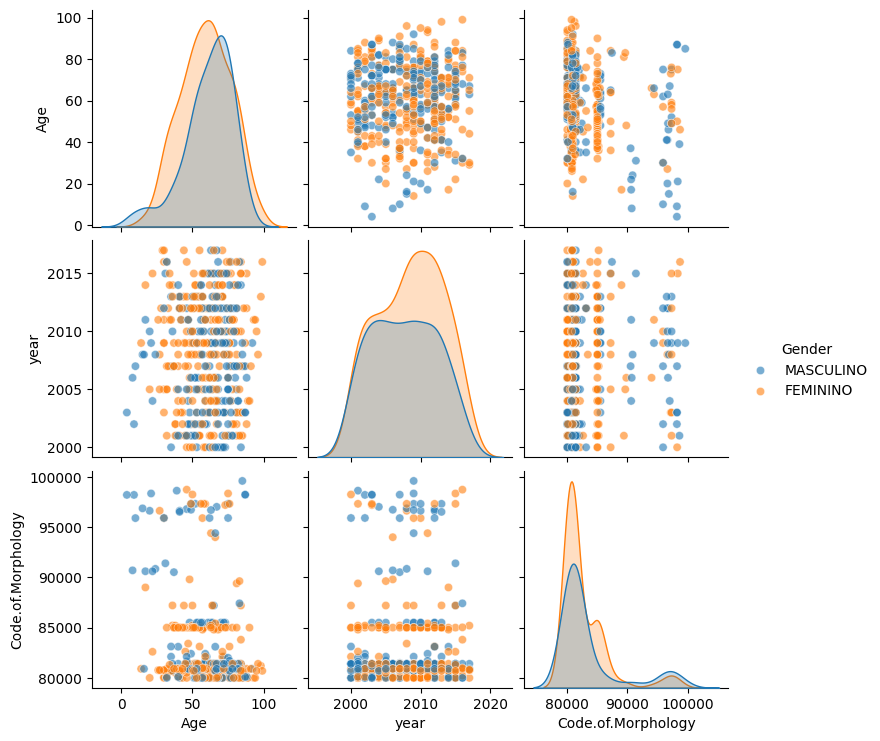

In [24]:
pair_data = pair_sample[["Age", "year", "Code.of.Morphology", "Gender"]].dropna()

sns.pairplot(
    pair_data,
    hue="Gender",
    diag_kind="kde",
    plot_kws={"alpha":0.6}
)

plt.show()

In [ ]:
# I used a pairplot to visualize relationships between age, year of diagnosis, and morphology codes (which describe the cancer cell type)
#i can also use this plot to see the distributtions of these variables aswell as how things change between male and female patients. 
# The most useful part of this is seeing that there is a lot of overlap between male and female observations.

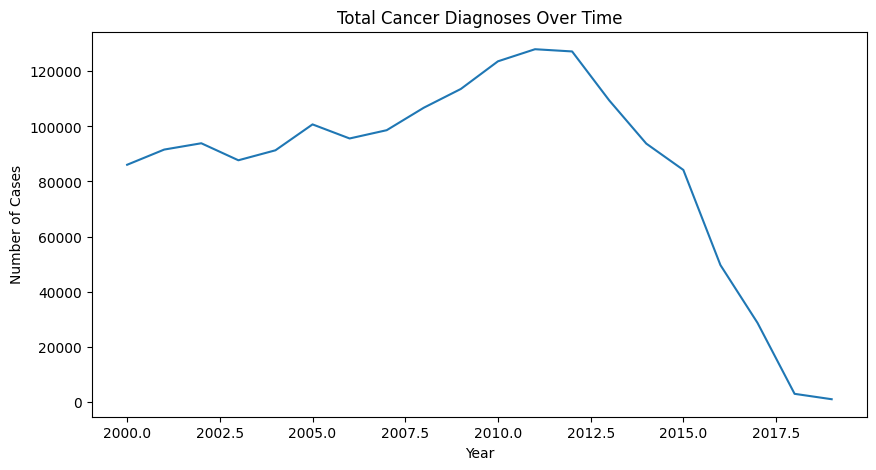

In [26]:
cases_per_year = df.groupby("year").size()

cases_per_year.plot(kind="line", figsize=(10,5))
plt.title("Total Cancer Diagnoses Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.show()

In [ ]:
#Interesting to see such a sharp decrease in cases around the 2012-2013 mark... It would be interesting to investigate to see if we could tie this back
# to an event. Maybe treatment got better?

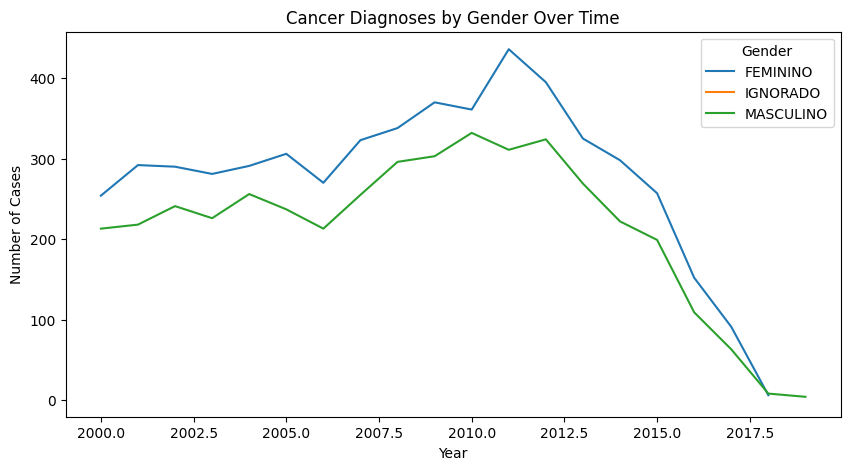

In [27]:
gender_year = df_sample.groupby(["year","Gender"]).size().unstack()

gender_year.plot(figsize=(10,5))
plt.title("Cancer Diagnoses by Gender Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.show()

In [ ]:
#Both genders share this same trend. 

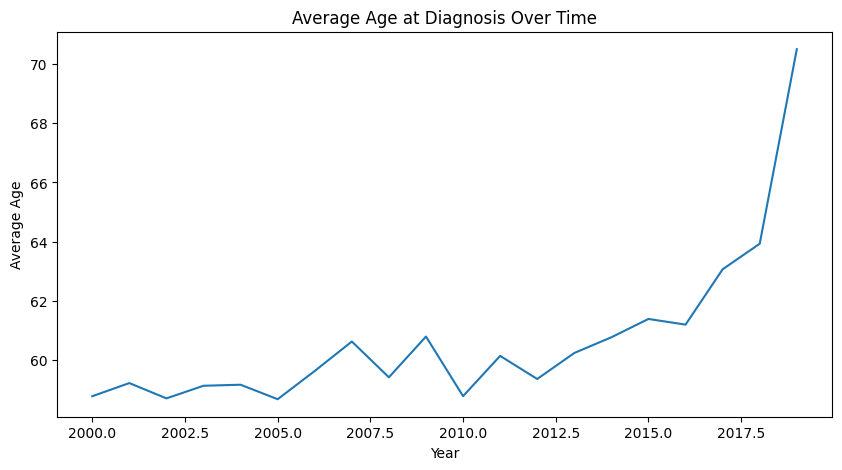

In [28]:
age_year = df_sample.groupby("year")["Age"].mean()

age_year.plot(figsize=(10,5))
plt.title("Average Age at Diagnosis Over Time")
plt.xlabel("Year")
plt.ylabel("Average Age")
plt.show()

In [ ]:
#Average age of diagnosis climbs steeply at the 2017 mark. 

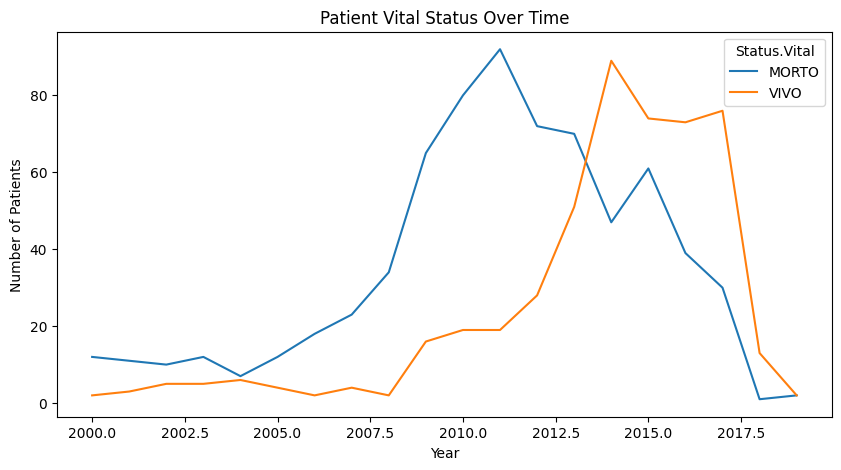

In [29]:
vital_year = df_sample.groupby(["year","Status.Vital"]).size().unstack()

vital_year.plot(figsize=(10,5))
plt.title("Patient Vital Status Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Patients")
plt.show()

In [30]:
# A sharp increase in cases leading to deaths around the 2010 mark which seems to have flipped by ~2013-2014

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

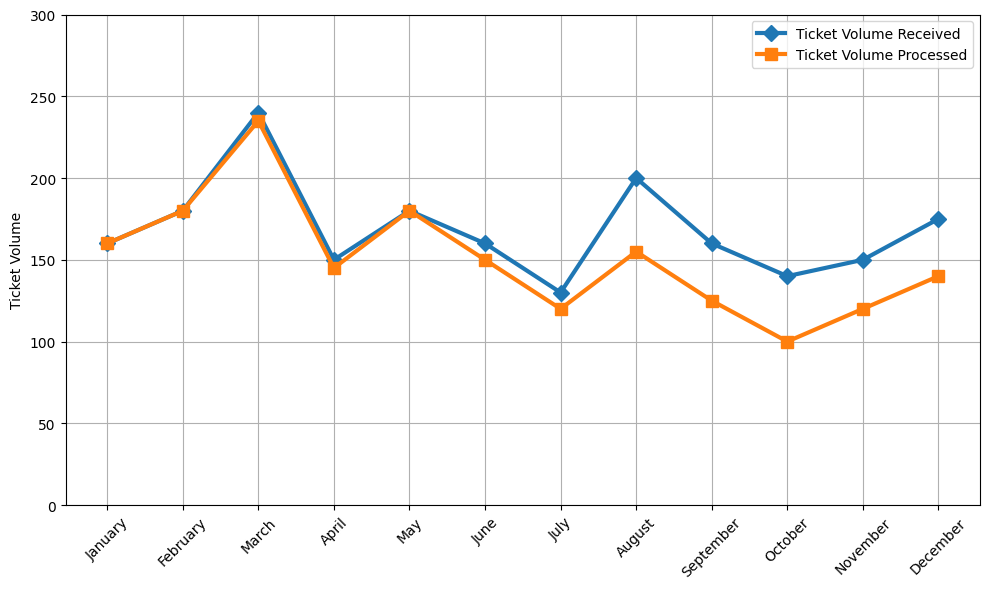

In [31]:
import matplotlib.pyplot as plt

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

received = [160, 180, 240, 150, 180, 160, 130, 200, 160, 140, 150, 175]
processed = [160, 180, 235, 145, 180, 150, 120, 155, 125, 100, 120, 140]

plt.figure(figsize=(10,6))

plt.plot(
    months,
    received,
    marker="D",
    markersize=8,
    linewidth=3,
    label="Ticket Volume Received"
)

plt.plot(
    months,
    processed,
    marker="s",
    markersize=8,
    linewidth=3,
    label="Ticket Volume Processed"
)
plt.ylabel("Ticket Volume")
plt.xticks(rotation=45)
plt.ylim(0,300)
plt.grid(True)

plt.legend()
plt.tight_layout()

plt.show()